# 01 — EDA de contraste: Sector formal (Planilla) vs Informalidad (ENAHO)

**Objetivo.** Contrastar la *composición del empleo formal* (Planilla Electrónica SUNAT/MTPE,
totales nacionales mensuales) frente a la *tasa de informalidad* medida a nivel individuo en la
ENAHO (módulo 500), 2015–2025, marcando la ventana **COVID (2020–2021)**.

> Nota metodológica: las dos fuentes no son unibles a nivel persona (Planilla son marginales
> nacionales). El contraste se hace **por año** y por dimensión (sexo, edad, área, sector).
> La tasa de informalidad ENAHO se pondera por el factor de expansión `fac500a`.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
plt.rcParams.update({'figure.dpi':110,'font.size':10,'axes.grid':True,'grid.alpha':.3})

ROOT = '/home/student2/labs/face/empleo/mtpe'
COLS = ['anio','sexo','grupo_edad','area_label','Y','fac500a',
        'pct_mujer_formal','pct_joven_formal','pct_mype_formal','pct_indefinido_formal',
        'pct_no_calificado_formal','total_formal',
        'pct_agropecuario_y_pesca','pct_manufactura','pct_comercio','pct_construccion',
        'pct_mineria_y_canteras','pct_servicios']
df = pd.read_csv(f'{ROOT}/data/interim/dataset_integrado.csv', usecols=COLS)
plan = pd.read_csv(f'{ROOT}/data/interim/planilla_limpia.csv')
COVID = (2020, 2021)

def shade_covid(ax):
    ax.axvspan(COVID[0]-0.5, COVID[1]+0.5, color='red', alpha=0.08, label='COVID')

def tasa_inf(d, by=None):
    """Tasa de informalidad ponderada (%) por año (y opcionalmente por grupo)."""
    keys = ['anio'] + (by or [])
    g = d.groupby(keys, observed=True).apply(
        lambda x: 100*np.average(x['Y'], weights=x['fac500a']))
    return g.rename('tasa_informal').reset_index()

nac = tasa_inf(df)
print(nac.to_string(index=False))

 anio  tasa_informal
 2015      73.150430
 2016      71.971619
 2017      72.546504
 2018      72.438371
 2019      72.740922
 2020      75.348519
 2021      76.846962
 2022      75.698908
 2023      73.884958
 2024      73.188526
 2025      72.429103


/tmp/ipykernel_4045727/528160885.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = d.groupby(keys, observed=True).apply(


## 1. Serie nacional — Informalidad ENAHO vs empleo formal (Planilla)

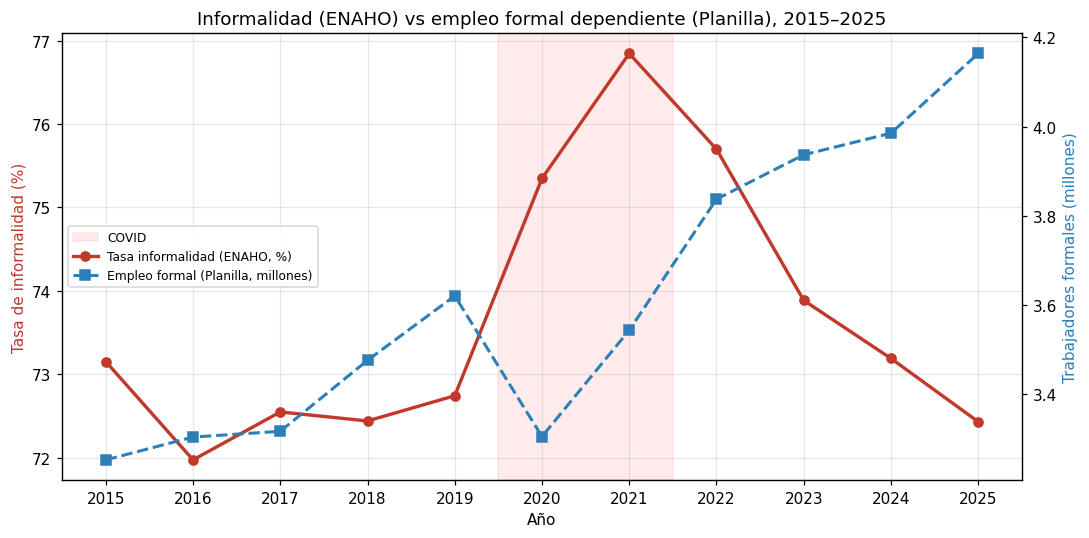

In [2]:
fig, ax1 = plt.subplots(figsize=(10,5))
shade_covid(ax1)
ax1.plot(nac['anio'], nac['tasa_informal'], 'o-', color='#c0392b', lw=2.2, label='Tasa informalidad (ENAHO, %)')
ax1.set_ylabel('Tasa de informalidad (%)', color='#c0392b')
ax1.set_xlabel('Año'); ax1.set_xticks(range(2015,2026))
ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(plan['AÑO'], plan['total_formal']/1e6, 's--', color='#2c7fb8', lw=2, label='Empleo formal (Planilla, millones)')
ax2.set_ylabel('Trabajadores formales (millones)', color='#2c7fb8')
ax1.set_title('Informalidad (ENAHO) vs empleo formal dependiente (Planilla), 2015–2025')
l1,la1 = ax1.get_legend_handles_labels(); l2,la2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, la1+la2, loc='center left', fontsize=8)
plt.tight_layout(); plt.show()

**Lectura.** La informalidad ENAHO sube en 2020 (shock COVID) mientras el empleo formal de
Planilla cae; la recuperación posterior del empleo formal coincide con el descenso de la
informalidad. Son fuerzas espejo del mismo mercado laboral.

## 2. Por sexo — Informalidad ENAHO vs participación femenina en el empleo formal

/tmp/ipykernel_4045727/528160885.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = d.groupby(keys, observed=True).apply(


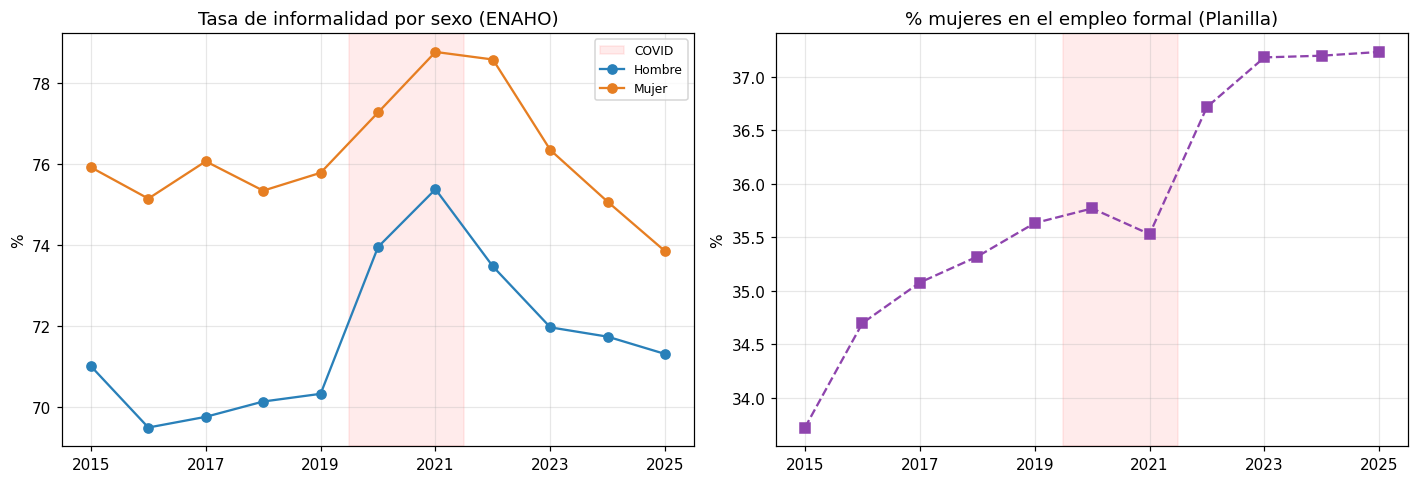

Brecha informalidad Mujer-Hombre (pp):
anio
2015    4.90
2016    5.64
2017    6.30
2018    5.20
2019    5.45
2020    3.32
2021    3.39
2022    5.10
2023    4.37
2024    3.32
2025    2.53


In [3]:
ts = tasa_inf(df, ['sexo'])
piv = ts.pivot(index='anio', columns='sexo', values='tasa_informal').rename(columns={1:'Hombre',2:'Mujer'})
fig, ax = plt.subplots(1,2, figsize=(13,4.5))
shade_covid(ax[0])
ax[0].plot(piv.index, piv['Hombre'],'o-',label='Hombre',color='#2980b9')
ax[0].plot(piv.index, piv['Mujer'],'o-',label='Mujer',color='#e67e22')
ax[0].set_title('Tasa de informalidad por sexo (ENAHO)'); ax[0].set_ylabel('%'); ax[0].legend(fontsize=8)
ax[0].set_xticks(range(2015,2026,2))
shade_covid(ax[1])
ax[1].plot(plan['AÑO'], 100*plan['pct_mujer_formal'],'s--',color='#8e44ad')
ax[1].set_title('% mujeres en el empleo formal (Planilla)'); ax[1].set_ylabel('%')
ax[1].set_xticks(range(2015,2026,2))
plt.tight_layout(); plt.show()
print('Brecha informalidad Mujer-Hombre (pp):')
print((piv['Mujer']-piv['Hombre']).round(2).to_string())

## 3. Por grupo de edad — Informalidad ENAHO vs jóvenes en el empleo formal

/tmp/ipykernel_4045727/528160885.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = d.groupby(keys, observed=True).apply(


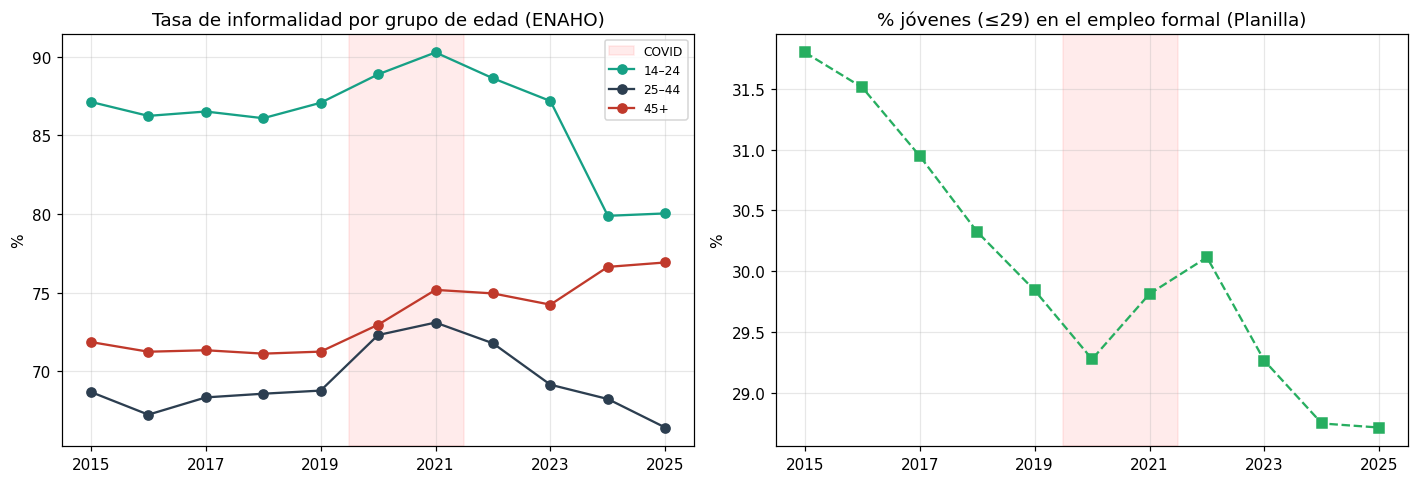

In [4]:
te = tasa_inf(df, ['grupo_edad'])
lab = {1.0:'14–24',2.0:'25–44',3.0:'45+'}
pe = te.pivot(index='anio', columns='grupo_edad', values='tasa_informal').rename(columns=lab)
fig, ax = plt.subplots(1,2, figsize=(13,4.5))
shade_covid(ax[0])
for c,col in zip(pe.columns, ['#16a085','#2c3e50','#c0392b']):
    ax[0].plot(pe.index, pe[c],'o-',label=c,color=col)
ax[0].set_title('Tasa de informalidad por grupo de edad (ENAHO)'); ax[0].set_ylabel('%'); ax[0].legend(fontsize=8)
ax[0].set_xticks(range(2015,2026,2))
shade_covid(ax[1])
ax[1].plot(plan['AÑO'], 100*plan['pct_joven_formal'],'s--',color='#27ae60')
ax[1].set_title('% jóvenes (≤29) en el empleo formal (Planilla)'); ax[1].set_ylabel('%')
ax[1].set_xticks(range(2015,2026,2))
plt.tight_layout(); plt.show()

## 4. Por área — Informalidad urbana vs rural (ENAHO)

/tmp/ipykernel_4045727/528160885.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = d.groupby(keys, observed=True).apply(


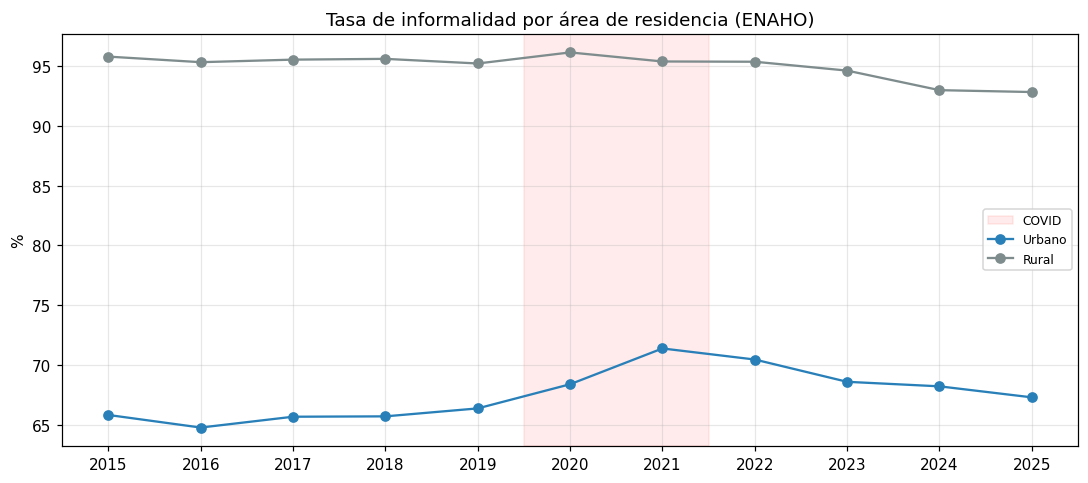

La informalidad rural supera ~90%; la urbana es el margen de política.


In [5]:
ta = tasa_inf(df, ['area_label']).pivot(index='anio', columns='area_label', values='tasa_informal')
fig, ax = plt.subplots(figsize=(10,4.5)); shade_covid(ax)
ax.plot(ta.index, ta['Urbano'],'o-',label='Urbano',color='#2980b9')
ax.plot(ta.index, ta['Rural'],'o-',label='Rural',color='#7f8c8d')
ax.set_title('Tasa de informalidad por área de residencia (ENAHO)')
ax.set_ylabel('%'); ax.set_xticks(range(2015,2026)); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('La informalidad rural supera ~90%; la urbana es el margen de política.')

## 5. Composición sectorial del empleo formal (Planilla) en el tiempo

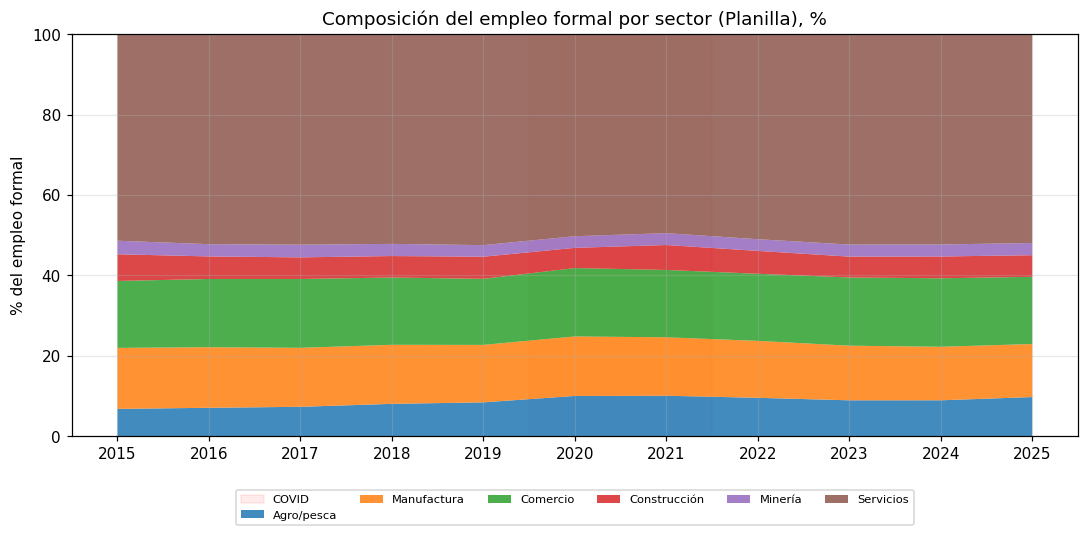

In [6]:
sec = ['pct_agropecuario_y_pesca','pct_manufactura','pct_comercio','pct_construccion',
       'pct_mineria_y_canteras','pct_servicios']
nice = ['Agro/pesca','Manufactura','Comercio','Construcción','Minería','Servicios']
S = plan.set_index('AÑO')[sec]*100
fig, ax = plt.subplots(figsize=(10,5)); shade_covid(ax)
ax.stackplot(S.index, *[S[c] for c in sec], labels=nice, alpha=.85)
ax.set_title('Composición del empleo formal por sector (Planilla), %')
ax.set_ylabel('% del empleo formal'); ax.set_xticks(range(2015,2026)); ax.set_ylim(0,100)
ax.legend(loc='upper center', ncol=6, fontsize=7.5, bbox_to_anchor=(0.5,-0.12))
plt.tight_layout(); plt.show()

## 6. Contraste COVID — variación 2019 → 2020/2021

In [7]:
def val(year): return float(nac.loc[nac.anio==year,'tasa_informal'].iloc[0])
base = val(2019)
comp = pd.DataFrame({
    'Indicador':['Informalidad ENAHO (%)','Empleo formal (millones)'],
    '2019':[base, float(plan.loc[plan.AÑO==2019,'total_formal'].iloc[0])/1e6],
    '2020':[val(2020), float(plan.loc[plan.AÑO==2020,'total_formal'].iloc[0])/1e6],
})
comp['Δ 2019→2020']= comp['2020']-comp['2019']
print(comp.round(3).to_string(index=False))
print(f"\nInformalidad +{val(2020)-base:.2f} pp en 2020; empleo formal cae "
      f"{(plan.loc[plan.AÑO==2020,'total_formal'].iloc[0]-plan.loc[plan.AÑO==2019,'total_formal'].iloc[0])/1e3:.0f} mil.")

               Indicador   2019   2020  Δ 2019→2020
  Informalidad ENAHO (%) 72.741 75.349        2.608
Empleo formal (millones)  3.621  3.306       -0.315

Informalidad +2.61 pp en 2020; empleo formal cae -315 mil.


## Hallazgos del EDA

- **Espejo macro:** cuando el empleo formal (Planilla) cae —shock COVID 2020— la informalidad
  (ENAHO) sube; la recuperación posterior es simétrica.
- **Sexo:** las mujeres muestran mayor informalidad que los hombres y baja participación en el
  empleo formal (~36%); brecha persistente en todo el periodo.
- **Edad:** los más jóvenes (14–24) y los mayores (45+) concentran más informalidad; los jóvenes
  son minoría en el empleo formal.
- **Área:** la informalidad rural se mantiene cerca del techo (~90%+); la urbana es el margen
  efectivo de política.
- **Sector formal:** dominado por Servicios y Comercio; estructura estable salvo el bache COVID.

Estos contrastes motivan el modelado de **determinantes** (ver `src/14_determinantes_temporal.py`),
donde categoría ocupacional, tamaño de empresa (MYPE) y sector resultan los factores de mayor peso.